# HPPC and Cycling Simulations compared with Data

In [ ]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import dfols
import signal
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq, fftshift
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from scipy import interpolate
from stopit import threading_timeoutable as timeoutable
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns import *
plt.rcParams = set_rc_params(plt.rcParams)

eSOH_DIR = "../data/esoh/"
oCV_DIR = "../data/ocv/"
hppc_DIR = "../data/hppc/"
crate_DIR = "../data/crate/"
cyc_DIR = "../data/cycling/"
fig_DIR = "../figures/figures_cycling/"
res_DIR = "../data/results/"

%matplotlib widget

In [ ]:
spm = pybamm.lithium_ion.SPM(
    {
        # "SEI": "ec reaction limited",
        # # "loss of active material": ("stress-driven","none"),
        # "loss of active material": "stress-driven",
        # "stress-induced diffusion": "true",
        # "lithium plating": "reversible",
    }
)
# spm.print_parameter_info()
param=spm.param

In [ ]:
parameter_values = get_parameter_values()

In [ ]:
cell = 1
cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
eps_n_data,eps_p_data,c_rate_c,c_rate_d,dis_set,Temp,SOC_0 = init_exp(cell_no,dfe,spm,parameter_values)
pybamm.set_logging_level("WARNING")
# pybamm.set_logging_level("NOTICE")

In [ ]:
parameter_values = get_parameter_values()
parameter_values.update(
    {
        "Positive electrode LAM constant proportional term [s-1]": 1.2676e-07,#2.7081e-07, #4.1759e-07,#2.7081e-07, #2.5112e-07,
        "Negative electrode LAM constant proportional term [s-1]": 1.2713e-06,#3.7576e-06, #3.2693e-06,#3.7576e-06, #2.4741e-06,
        "Positive electrode LAM constant exponential term": 1.1998,#1.2446,#1.2232,#1.1942,
        "Negative electrode LAM constant exponential term": 1.1998,#1.2446,#1.2232,#1.1942,
        "Negative electrode active material volume fraction": eps_n_data,
        "Positive electrode active material volume fraction": eps_p_data,
        "Initial temperature [K]": 273.15+Temp,
        "Ambient temperature [K]": 273.15+Temp,
        "SEI kinetic rate constant [m.s-1]": 1.08494281e-16,
        "EC diffusivity [m2.s-1]": 8.30909086e-19,
        "SEI growth activation energy [J.mol-1]": 1.58777981e+04,
        # "SEI kinetic rate constant [m.s-1]": 1.6827e-16,
        # "EC diffusivity [m2.s-1]": 2e-18,
        # "SEI growth activation energy [J.mol-1]": 0,
    },
    check_already_exists=False,
)

In [ ]:
loc = 0
model = spm
Vmin = 3.0
Vmax = 4.2
esoh_model = pybamm.lithium_ion.ElectrodeSOH()
esoh_sim = pybamm.Simulation(esoh_model, parameter_values=parameter_values)
Cn = dfe["C_n"].iloc[loc]
# print(Cn)
Cp = dfe["C_p"].iloc[loc]
n_Li_init = dfe["n_Li"].iloc[loc]
c_n_max = parameter_values.evaluate(param.n.prim.c_max)
c_p_max = parameter_values.evaluate(param.p.prim.c_max)
eps_n_data = parameter_values.evaluate(Cn*3600/(param.n.L * param.n.prim.c_max * param.F* param.A_cc))
eps_p_data = parameter_values.evaluate(Cp*3600/(param.p.L * param.p.prim.c_max * param.F* param.A_cc))
esoh_sol = esoh_sim.solve(
        [0],
        inputs={"V_min": Vmin, "V_max": Vmax, "C_n": Cn, "C_p": Cp, "n_Li": n_Li_init},
        solver=pybamm.AlgebraicSolver(),
    )

parameter_values.update(
    {
        "Initial concentration in negative electrode [mol.m-3]": esoh_sol[
    "x_100"
        ].data[0]
        * c_n_max,
        "Initial concentration in positive electrode [mol.m-3]": esoh_sol[
            "y_100"
        ].data[0]
        * c_p_max,
        "Negative electrode active material volume fraction": eps_n_data,
        "Positive electrode active material volume fraction": eps_p_data,
        "Initial temperature [K]": 273.15+25,
        "Ambient temperature [K]": 273.15+25,
        
    }
)

In [ ]:
hppc_data_raw = pd.read_csv(hppc_DIR+'hppc_data_cell_'+cell_no+'.csv')


In [ ]:
N = 41
hppc_data_raw = pd.read_csv(hppc_DIR+'hppc_data_cell_'+cell_no+'.csv')
hppc_data_raw = hppc_data_raw[ hppc_data_raw['Cycle number'] == N ]
hppc_data_raw = hppc_data_raw.reset_index(drop=True)
idx_hppc = hppc_data_raw['Current [mA]'].lt(0).idxmax()
hppc_data = hppc_data_raw.iloc[idx_hppc:,:]
hppc_data = hppc_data.reset_index(drop=True)
data_time = hppc_data['Time [s]']-hppc_data['Time [s]'][0]
data_time = data_time.values
data_current = hppc_data['Current [mA]']/1000
data_current = data_current.values
data_voltage = hppc_data['Voltage [V]']
data_voltage = data_voltage.values

In [ ]:
t_sim = np.arange(0,data_time[-1],0.1)
timescale = parameter_values.evaluate(spm.timescale)
current_interpolant = pybamm.Interpolant(
  #  drive_cycle[:, 0], drive_cycle[:, 1], timescale * pybamm.t
  data_time, -data_current, timescale * pybamm.t
)

In [ ]:
pybamm.set_logging_level("NOTICE")
parameter_values["Current function [A]"] = current_interpolant
# var_pts=var_pts,
sim = pybamm.Simulation(spm, 
                        parameter_values=parameter_values, 
                        solver=pybamm.CasadiSolver(
                            mode="safe", 
                            rtol=1e-6, 
                            atol=1e-6,
                            dt_max=1,
                            )
                        )
# sim.solve(t_eval=data_time,initial_soc =1)
sim.solve(t_eval=t_sim,initial_soc =1)
solution = sim.solution

In [ ]:
t = solution["Time [s]"].entries
V = solution["Terminal voltage [V]"].entries
I = solution["Current [A]"].entries
Q = -solution['Discharge capacity [A.h]'].entries

In [ ]:
Temp = 45
parameter_values.update(
    {
        "Initial temperature [K]": 273.15+Temp,
        "Ambient temperature [K]": 273.15+Temp,
    },
    check_already_exists=False,
)

In [ ]:
pybamm.set_logging_level("NOTICE")
parameter_values["Current function [A]"] = current_interpolant
# var_pts=var_pts,
sim = pybamm.Simulation(spm, 
                        parameter_values=parameter_values, 
                        solver=pybamm.CasadiSolver(
                            mode="safe", 
                            rtol=1e-6, 
                            atol=1e-6,
                            dt_max=1,
                            )
                        )
# sim.solve(t_eval=data_time,initial_soc =1)
sim.solve(t_eval=t_sim,initial_soc =1)
solution1= sim.solution

In [ ]:
t1 = solution1["Time [s]"].entries
V1 = solution1["Terminal voltage [V]"].entries
I1 = solution1["Current [A]"].entries
Q1 = -solution1['Discharge capacity [A.h]'].entries

In [ ]:
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6), sharex=True)
# ax1.plot(data_time, data_voltage, 'k')
ax1.plot(t, V, 'g--')
ax1.plot(t1, V1, 'r--')
# ax1.plot(t1, V1, 'r-.')
ax1.set_ylabel("Voltage [V]")
ax1.set_title("Cell 01 BOL HPPC")
# ax1.set_ylim([2.7,4.2])
ax1.set_xlabel("Time [s]")
# ax1.set_xlim([20370,20470])
ax1.legend(['Room','Hot'])
# ax1.legend(['data','sim','sim new'])
fig.tight_layout()
plt.show()
plt.savefig('cell_01_hppc_room_hot.png')

In [ ]:
dfgdfgdfgdfg

In [ ]:
# idxi = np.where((np.diff(data_current)>-2.5) & (np.diff(data_current)<-1.5) & (abs(data_current[:-1])<1))[0]
data_currents = np.insert(data_current,0,0)
idxi = np.where((np.diff(data_currents)<-0.1) & (data_current<-4.5))[0]
idxd = np.insert(idxi,idxi.size,len(data_current)-1)

In [21]:
Is = np.insert(I,0,0)
idxi = np.where((np.diff(-Is)<-0.1) & (abs(I)>4.9))[0]
idx = np.insert(idxi,idxi.size,len(I)-1)

In [23]:
Is = np.insert(I1,0,0)
idxi = np.where((np.diff(-Is)<-0.1) & (abs(I)>4.9))[0]
idx1 = np.insert(idxi,idxi.size,len(I1)-1)

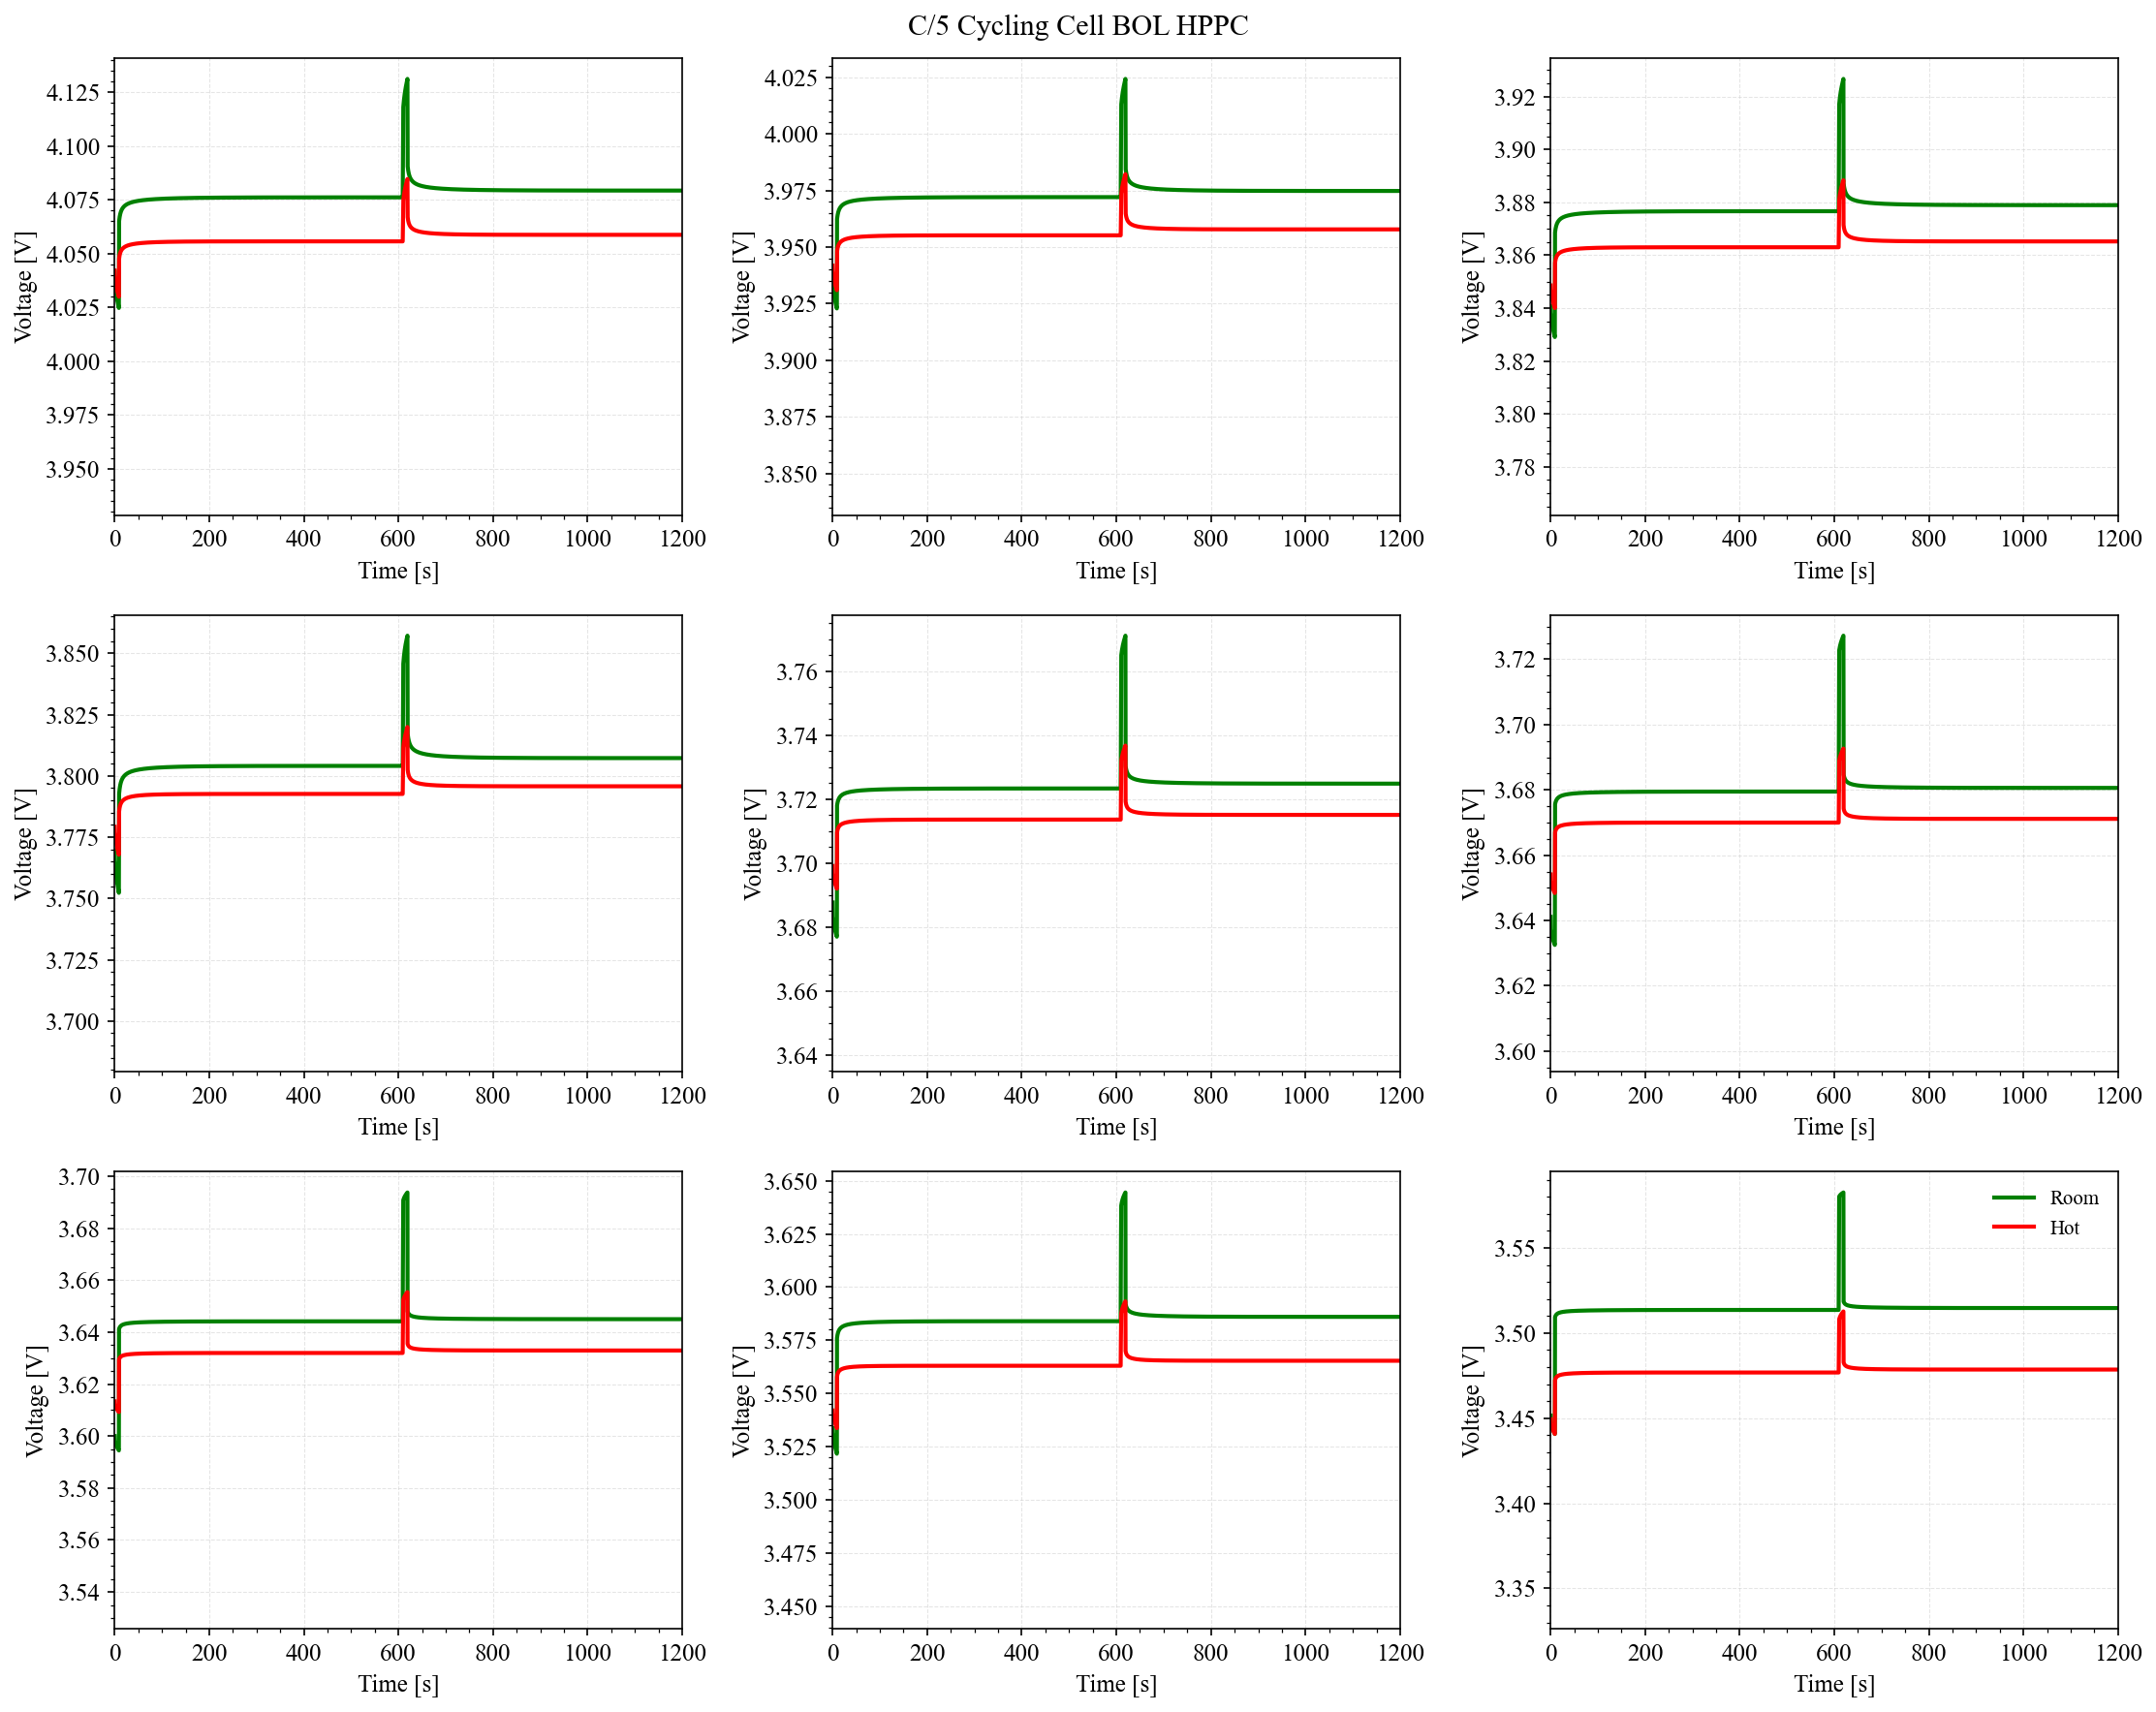

In [24]:
i = 0
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ii in range(0,9):
    ax1=axes.flat[ii]
    ax1.plot(t[idx[ii]-10:idx[ii+1]]-t[idx[ii]], V[idx[ii]-10:idx[ii+1]], 'g')
    ax1.plot(t1[idx1[ii]-10:idx1[ii+1]]-t1[idx1[ii]], V1[idx1[ii]-10:idx1[ii+1]], 'r')
    # ax1.plot(t1, V1, 'r-.')
    ax1.set_ylabel("Voltage [V]")
    # ax1.set_title("Cell 01 Fresh HPPC")
    # ax1.set_ylim([data_voltage[idxd[ii]]-0.05,max(data_voltage[idxd[ii]-10:idxd[ii+1]])+0.05])
    ax1.set_xlim([0,1200])
    ax1.set_xlabel("Time [s]")
    # ax1.set_xlim([20370,20470])
    i+=1
ax1.legend(['Room','Hot'])
fig.suptitle("C/5 Cycling Cell BOL HPPC")
fig.tight_layout()
plt.show()
plt.savefig('cell_01_BOL_hppc_pulses_hot_room.png')
# plt.savefig('cell_01_EOL_hppc_pulses.png')

In [ ]:
ii = 0
t_d1 = data_time[idxd[ii]:idxd[ii+1]]-data_time[idxd[ii]]
V_d1 = data_voltage[idxd[ii]:idxd[ii+1]]
t_s1 = t[idx[ii]:idx[ii+1]]-t[idx[ii]]
V_s1 = V[idx[ii]:idx[ii+1]]
V_diff = data_voltage[idxd[ii]-10]-V[idx[ii]-10]
V_sn1 = V_s1 + V_diff
idxs1 = np.where( (abs(t_s1-1200)<1))[0][-1]
idxd1 = np.where( (abs(t_d1-1200)<1))[0][-1]
t_s = t_s1[:idxs1]
V_s = V_s1[:idxs1]
V_sn = V_sn1[:idxs1]
t_d = t_d1[:idxd1]
V_d = V_d1[:idxd1]
int_V = interpolate.CubicSpline(t_s,V_sn,extrapolate=True)
rmse_V = pybamm.rmse(V_d,int_V(t_d))

In [ ]:
fig, ax = plt.subplots(1, 1)
ax.plot(V_s,'bx')
ax.plot(V_d,'ro')

In [ ]:
idxi

In [ ]:
i = 0
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ii in range(0,9):
    ax1=axes.flat[ii]
    ax1.plot(data_time[idxd[ii]-10:idxd[ii+1]]-data_time[idxd[ii]], data_voltage[idxd[ii]-10:idxd[ii+1]], 'k')
    ax1.plot(t[idx[ii]-10:idx[ii+1]]-t[idx[ii]], V[idx[ii]-10:idx[ii+1]], 'b--')
    ax1.plot(t[idx[ii]-10:idx[ii+1]]-t[idx[ii]], V[idx[ii]-10:idx[ii+1]]+data_voltage[idxd[ii]-10]-V[idx[ii]-10], 'r--')
    # ax1.plot(t1, V1, 'r-.')
    ax1.set_ylabel("Voltage [V]")
    # ax1.set_title("Cell 01 Fresh HPPC")
    ax1.set_ylim([data_voltage[idxd[ii]]-0.05,max(data_voltage[idxd[ii]-10:idxd[ii+1]])+0.05])
    ax1.set_xlim([0,1200])
    ax1.set_xlabel("Time [s]")
    # ax1.set_xlim([20370,20470])
    i+=1
ax1.legend(['data','sim','sim shifted'])
fig.suptitle("C/5 Cycling Cell BOL HPPC")
fig.tight_layout()
plt.show()
plt.savefig('cell_01_BOL_hppc_pulses.png')
# plt.savefig('cell_01_EOL_hppc_pulses.png')

In [ ]:
ertr

In [ ]:
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6), sharex=True)
ax1.plot(t, data_voltage[:14202]-V, 'k')
# ax1.plot(t, V, 'b--')
# ax1.plot(t1, V1, 'r-.')
ax1.set_ylabel("Voltage [V]")
ax1.set_title("Cell 01 Fresh HPPC")
ax1.set_ylim([-0.05,0.05])
ax1.set_xlabel("Time [s]")
# ax1.set_xlim([20370,20470])
ax1.legend(['data','sim'])
fig.tight_layout()
plt.show()
plt.savefig('cell_01_hppc_fit_diff.png')

In [ ]:
dfsdfsdfs

In [ ]:
# spm.default_var_pts

In [ ]:
var_pts = {
    'x_n': 30,
    'x_s': 30,
    'x_p': 30,
    'r_n': 60,
    'r_p': 60,
    'r_n_prim': 60,
    'r_p_prim': 60,
    'r_n_sec': 60,
    'r_p_sec': 60,
    'y': 20,
    'z': 20,
    'R_n': 60,
    'R_p': 60,
 }

In [ ]:
# def graphite_diffusivity(sto, T):
#     from pybamm import exp, constants
#     # D_ref = 5.0 * 10 ** (-15)
#     D_ref = 5.0/2* 10 ** (-15)
#     E_D_s = 42770
#     arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))

#     return D_ref * arrhenius

# def NMC_diffusivity(sto, T):
#     from pybamm import exp, constants
#     # D_ref = 8 * 10 ** (-15)
#     D_ref = 1.5 * 10 ** (-15)
#     E_D_s = 18550
#     arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))

#     return D_ref * arrhenius

In [ ]:
# parameter_values.update(
#     {
#         "Negative electrode diffusivity [m2.s-1]": graphite_diffusivity,
#         "Positive electrode diffusivity [m2.s-1]": NMC_diffusivity,

#     },
#     check_already_exists=False,
# )

In [ ]:
# sim = pybamm.Simulation(spm, parameter_values=parameter_values, solver=pybamm.CasadiSolver(mode="safe", rtol=1e-6, atol=1e-6,dt_max=0.1))
# sim.solve(t_eval=data_time,initial_soc =1)
# solution1 = sim.solution

In [ ]:
# t1 =  solution1["Time [s]"].entries
# V1 =  solution1["Terminal voltage [V]"].entries
# I1 =  solution1["Current [A]"].entries
# Q1 = -solution1['Discharge capacity [A.h]'].entries

In [ ]:
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6), sharex=True)
ax1.plot(data_time, data_voltage, 'k')
ax1.plot(t, V, 'b--')
# ax1.plot(t1, V1, 'r-.')
ax1.set_ylabel("Voltage [V]")
ax1.set_title("Cell 01 Fresh HPPC")
ax1.set_ylim([2.7,4.2])
ax1.set_xlabel("Time [s]")
# ax1.set_xlim([20370,20470])
ax1.legend(['data','sim'])
# ax1.legend(['data','sim','sim new'])
fig.tight_layout()
plt.show()
# plt.savefig('cell_01_hppc_fit.png')

In [ ]:
fig, ax1 = plt.subplots(1, 1, figsize=(4, 4), sharex=True)
ax1.plot(data_time, -data_current, 'k', t, I, 'r--')
ax1.set_title("Current [A]")
# ax1.set_ylim([3.9,4.12])
ax1.set_xlabel("Time [s]")
# ax1.set_xlim([20370,20470])
ax1.legend(['data','sim'])
fig.tight_layout()
plt.show()
# plt.savefig('cell_01_hppc_fit.png')

In [ ]:
asdasdasdasd

# Crate Simulations

In [ ]:
crate_data_raw = pd.read_csv(crate_DIR+'crate_data_cell_'+cell_no+'.csv')
crate_data_raw = crate_data_raw[ crate_data_raw['Cycle number'] == 0 ]

In [ ]:
# idx_crate = crate_data_raw['Current [mA]'].gt(0).idxmax()
# crate_data = crate_data_raw.iloc[idx_crate:,:]
# crate_data = crate_data.reset_index(drop=True)

In [ ]:
crate_data = crate_data_raw

In [ ]:
t_d1 = crate_data['Time [s]']-crate_data['Time [s]'][0]
t_d1 = t_d1.values
I_d1 = crate_data['Current [mA]']/1000
I_d1 = I_d1.values
V_d1 = crate_data['Voltage [V]']
V_d1 = V_d1.values

In [ ]:
idx_I = np.where(np.sign(I_d1[:-1]) != np.sign(I_d1[1:]))[0] + 1
idx_I = idx_I[idx_I>50]

In [ ]:
# C/10
nn = 0
t_d1_c10 = t_d1[idx_I[nn+0]:idx_I[nn+1]]-t_d1[idx_I[nn+0]]
I_d1_c10 = I_d1[idx_I[nn+0]:idx_I[nn+1]]
V_d1_c10 = V_d1[idx_I[nn+0]:idx_I[nn+1]]
# C/5
nn = 4
t_d1_c5 = t_d1[idx_I[nn+0]:idx_I[nn+1]]-t_d1[idx_I[nn+0]]
I_d1_c5 = I_d1[idx_I[nn+0]:idx_I[nn+1]]
V_d1_c5 = V_d1[idx_I[nn+0]:idx_I[nn+1]]
# C/2
nn = 8
t_d1_c2 = t_d1[idx_I[nn+0]:idx_I[nn+1]]-t_d1[idx_I[nn+0]]
I_d1_c2 = I_d1[idx_I[nn+0]:idx_I[nn+1]]
V_d1_c2 = V_d1[idx_I[nn+0]:idx_I[nn+1]]
# 1C
nn = 12
t_d1_c1 = t_d1[idx_I[nn+0]:idx_I[nn+1]]-t_d1[idx_I[nn+0]]
I_d1_c1 = I_d1[idx_I[nn+0]:idx_I[nn+1]]
V_d1_c1 = V_d1[idx_I[nn+0]:idx_I[nn+1]]

In [ ]:
# fig, axes = plt.subplots(2, 1, figsize=(6, 6), sharex=True)
# ax1 = axes.flat[0]
# # ax1.plot(crate_data['Time [s]'],crate_data['Voltage [V]'])
# ax1.plot(t_d1_c10,V_d1_c10)
# ax1.plot(t_d1_c5,V_d1_c5)
# ax1.plot(t_d1_c2,V_d1_c2)
# ax1.plot(t_d1_c1,V_d1_c1)
# ax1.set_title("Voltage [V]")
# ax1.set_xlabel("Time [s]")
# ax2 = axes.flat[1]
# # ax2.plot(crate_data['Time [s]'],crate_data['Current [mA]'])
# ax2.plot(t_d1_c10,I_d1_c10)
# ax2.plot(t_d1_c5,I_d1_c5)
# ax2.plot(t_d1_c2,I_d1_c2)
# ax2.plot(t_d1_c1,I_d1_c1)
# ax2.set_title("Current [mA]'")
# ax2.set_xlabel("Time [s]")
# fig.tight_layout()
# plt.show()

In [ ]:
# fig, axes = plt.subplots(2, 1, figsize=(6, 6), sharex=True)
# ax1 = axes.flat[0]
# # ax1.plot(crate_data['Time [s]'],crate_data['Voltage [V]'])
# ax1.plot(t_d1,V_d1)
# ax1.set_title("Voltage [V]")
# ax1.set_xlabel("Time [s]")
# ax2 = axes.flat[1]
# # ax2.plot(crate_data['Time [s]'],crate_data['Current [mA]'])
# ax2.plot(t_d1,I_d1)
# ax2.plot(t_d1[idx_I],I_d1[idx_I],'x')
# ax2.set_title("Current [mA]'")
# ax2.set_xlabel("Time [s]")
# fig.tight_layout()
# plt.show()
# # plt.savefig('cell_01_hppc_fit.png')

In [ ]:
experiment = pybamm.Experiment(
    [
        "Charge at "+"C/10"+" until 4.2V", 
         
    ],
)
sim = pybamm.Simulation(spm,experiment=experiment ,parameter_values=parameter_values, solver=pybamm.CasadiSolver(mode="safe"))
sim.solve(t_eval=data_time,initial_soc =0)
solution1 = sim.solution

In [ ]:
experiment = pybamm.Experiment(
    [
        "Charge at "+"C/5"+" until 4.2V", 
         
    ],
)
sim = pybamm.Simulation(spm,experiment=experiment ,parameter_values=parameter_values, solver=pybamm.CasadiSolver(mode="safe"))
sim.solve(t_eval=data_time,initial_soc =0)
solution2 = sim.solution

In [ ]:
experiment = pybamm.Experiment(
    [
        "Charge at "+"C/2"+" until 4.2V", 
         
    ],
)
sim = pybamm.Simulation(spm,experiment=experiment ,parameter_values=parameter_values, solver=pybamm.CasadiSolver(mode="safe"))
sim.solve(t_eval=data_time,initial_soc =0)
solution3 = sim.solution

In [ ]:
experiment = pybamm.Experiment(
    [
        "Charge at "+"1C"+" until 4.2V", 
         
    ],
)
sim = pybamm.Simulation(spm,experiment=experiment ,parameter_values=parameter_values, solver=pybamm.CasadiSolver(mode="safe"))
sim.solve(t_eval=data_time,initial_soc =0)
solution4 = sim.solution

In [ ]:
t1 =  solution1["Time [s]"].entries
V1 =  solution1["Terminal voltage [V]"].entries
I1 =  solution1["Current [A]"].entries
Q1 = -solution1['Discharge capacity [A.h]'].entries

t2 =  solution2["Time [s]"].entries
V2 =  solution2["Terminal voltage [V]"].entries
I2 =  solution2["Current [A]"].entries
Q2 = -solution2['Discharge capacity [A.h]'].entries

t3 =  solution3["Time [s]"].entries
V3 =  solution3["Terminal voltage [V]"].entries
I3 =  solution3["Current [A]"].entries
Q3 = -solution3['Discharge capacity [A.h]'].entries

t4 =  solution4["Time [s]"].entries
V4 =  solution4["Terminal voltage [V]"].entries
I4 =  solution4["Current [A]"].entries
Q4 = -solution4['Discharge capacity [A.h]'].entries

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
ax1 = axes.flat[0]
ax2 = axes.flat[1]
ax3 = axes.flat[2]
ax4 = axes.flat[3]
ax1.plot(t_d1_c10, V_d1_c10, 'k', t1, V1, 'r--')
ax2.plot(t_d1_c5, V_d1_c5, 'k', t2, V2, 'r--')
ax3.plot(t_d1_c2, V_d1_c2, 'k', t3, V3, 'r--')
ax4.plot(t_d1_c1, V_d1_c1, 'k', t4, V4, 'r--')
ax1.set_title('C/10')
ax2.set_title('C/5')
ax3.set_title('C/2')
ax4.set_title('1C')
ax1.set_ylabel("Voltage [V]")
ax3.set_ylabel("Voltage [V]")
# ax1.set_ylim([3.9,4.12])
ax3.set_xlabel("Time [s]")
ax4.set_xlabel("Time [s]")
# ax1.set_xlim([20370,20470])
ax1.legend(['data','sim'])
fig.tight_layout()
plt.show()
plt.savefig('cell_01_crate_fit.png')

In [ ]:
dfasddasdasdas

# Simulate Pulse

In [ ]:
experiment = pybamm.Experiment(
    [
        (
         "Rest for 300 sec",
         "Discharge at "+ "5A"+ " for 10 sec", 
         "Rest for 300 sec",
         "Charge at "+ "5A"+ " for 10 sec", 
         "Rest for 300 sec",
         )
    ],
#     cccv_handling="ode",
)

In [ ]:
# t_in0 = 2
# t_in1 = 2
# t_in2 = 2
# t_in3 = 2
# t_in4 = 2

t_in0 = 300
t_in1 = 10
t_in2 = 300
t_in3 = 10
t_in4 = 300

t_inf = t_in0+t_in1+t_in2+t_in3+t_in4
t_in = np.arange(0,t_inf,0.1)
t_in = np.arange(0,t_inf,1)
# t_sim = np.arange(0,t_inf,0.01)
I_in = []
for tt in t_in:
    if tt<t_in0:
        I_in = np.append(I_in,0)
    elif tt>=t_in0 and tt<t_in0+t_in1:
        I_in = np.append(I_in,5)
    elif tt>=t_in0+t_in1 and tt<t_in0+t_in1+t_in2:
        I_in = np.append(I_in,0)
    elif tt>=t_in0+t_in1+t_in2 and tt<t_in0+t_in1+t_in2+t_in3:
        I_in = np.append(I_in,-5)
    elif tt>=t_in0+t_in1+t_in2+t_in3:
        I_in = np.append(I_in,0)
# I_in = np.array([0,0,5,5,0,0,-5,-5,0,0])

In [ ]:
timescale = parameter_values.evaluate(spm.timescale)
current_interpolant = pybamm.Interpolant(
  #  drive_cycle[:, 0], drive_cycle[:, 1], timescale * pybamm.t
  t_in, -I_in, timescale * pybamm.t
)

In [ ]:
parameter_values["Current function [A]"] = current_interpolant
pybamm.set_logging_level("WARNING")
sim = pybamm.Simulation(spm, 
                        parameter_values=parameter_values, 
                        # experiment=experiment,
                        solver=pybamm.CasadiSolver(mode="safe", rtol=1e-6, atol=1e-6,dt_max=10),
                        )
# sim.solve(initial_soc =0.9)
sim.solve(t_eval=t_in,initial_soc =0.9)
solution5 = sim.solution

In [ ]:
t5 =  solution5["Time [s]"].entries
V5 =  solution5["Terminal voltage [V]"].entries
I5 =  solution5["Current [A]"].entries
Q5 = -solution5['Discharge capacity [A.h]'].entries

cs_sur_n_5 =   solution5["X-averaged negative particle surface concentration"].entries
cs_sur_p_5 =   solution5["X-averaged positive particle surface concentration"].entries
cs_ave_n_5 =   solution5["Negative electrode volume-averaged concentration"].entries
cs_ave_p_5 =   solution5["Positive electrode volume-averaged concentration"].entries

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(6, 8))
ax1 = axes.flat[0]
ax2 = axes.flat[1]
ax3 = axes.flat[2]
ax4 = axes.flat[3]
ax1.plot(t5, V5)
ax1.set_ylabel('Voltage [V]')
ax2.plot(t5, I5)
ax2.set_ylabel('Current [A]')
ax3.plot(t5,cs_sur_n_5,'m--',t5,cs_ave_n_5,'m')
ax3.set_ylabel('Concentration [normalized]')
ax3.legend(['Surface','Average'])
ax3.set_title('Negative Particle Stoichiometry')
ax4.plot(t5,cs_sur_p_5,'g--',t5,cs_ave_p_5,'g')

ax4.set_ylabel('Concentration [normalized]')
ax4.set_title('Positive Particle Stoichiometry')
ax4.legend(['Surface','Average'])
ax4.axvline(x = t_in0, color = 'k', linestyle='--',linewidth=0.5,clip_on=False,ymin=0,ymax=5.5)
ax4.axvline(x = t_in0+t_in1+t_in2, color = 'k', linestyle='--',linewidth=0.5,clip_on=False,ymin=0,ymax=5.5)
# ax1.set_xlim([20370,20470])
# ax1.legend(['data','sim'])
fig.tight_layout()
plt.savefig('cell_01_pulse_V_sam.png')

In [ ]:
plt.figure()
plt.plot(t5,cs_sur_n_5-cs_ave_n_5,'b')
plt.plot(t5,cs_sur_p_5-cs_ave_p_5,'r')
plt.xlim(left=0)
plt.xlabel('Time [s]')
plt.ylabel('Concentration [normalized]')
plt.title('Difference between Surface and Average Particle Concentration')
plt.legend(['Negative','Positive'])
# plt.savefig('cell_01_conc_V.png')

# Cycling Simulations

In [ ]:
cell = 13
cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
print(cell_no)
eps_n_data,eps_p_data,c_rate_c,c_rate_d,dis_set,Temp,SOC_0 = init_exp(cell_no,dfe,spm,parameter_values)
cyc_data_raw = pd.read_csv(cyc_DIR+'cycling_data_cell_'+cell_no+'.csv')
cyc_data_raw = cyc_data_raw[ cyc_data_raw['Cycle number'] == 1 ]
cyc_data = cyc_data_raw.reset_index(drop=True)
# cyc_data = cyc_data_raw
t_c1 = cyc_data['Time [s]']-cyc_data['Time [s]'][0]
t_c1 = t_c1.values
I_c1 = cyc_data['Current [mA]']/1000
I_c1 = I_c1.values
V_c1 = cyc_data['Voltage [V]']
V_c1 = V_c1.values
T_c1 = cyc_data['Temperature [C]']
T_c1 = T_c1.values
T_c1

In [ ]:
# for cell in range(1,22,3):
for cell in range(3,22,3):
# for cell in [20]:
  cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
  print(cell_no)
  eps_n_data,eps_p_data,c_rate_c,c_rate_d,dis_set,Temp,SOC_0 = init_exp(cell_no,dfe,spm,parameter_values)
  cyc_data_raw = pd.read_csv(cyc_DIR+'cycling_data_cell_'+cell_no+'.csv')
  if int(cell_no)%3 == 1:
    cyc_data_raw = cyc_data_raw[ cyc_data_raw['Cycle number'] == 1 ]
  else:
    cyc_data_raw = cyc_data_raw[ cyc_data_raw['Cycle number'] == 1 ]
  cyc_data = cyc_data_raw.reset_index(drop=True)
  t_c1 = cyc_data['Time [s]']-cyc_data['Time [s]'][0]
  t_c1 = t_c1.values
  I_c1 = cyc_data['Current [mA]']/1000
  I_c1 = I_c1.values
  V_c1 = cyc_data['Voltage [V]']
  V_c1 = V_c1.values
  parameter_values = get_parameter_values()
  parameter_values.update(
      {
          "Positive electrode LAM constant proportional term [s-1]": 1.2676e-07,#2.7081e-07, #4.1759e-07,#2.7081e-07, #2.5112e-07,
          "Negative electrode LAM constant proportional term [s-1]": 1.2713e-06,#3.7576e-06, #3.2693e-06,#3.7576e-06, #2.4741e-06,
          "Positive electrode LAM constant exponential term": 1.1998,#1.2446,#1.2232,#1.1942,
          "Negative electrode LAM constant exponential term": 1.1998,#1.2446,#1.2232,#1.1942,
          "Negative electrode active material volume fraction": eps_n_data,
          "Positive electrode active material volume fraction": eps_p_data,
          "Initial temperature [K]": 273.15+Temp,
          "Ambient temperature [K]": 273.15+Temp,
          "SEI kinetic rate constant [m.s-1]": 1.08494281e-16,
          "EC diffusivity [m2.s-1]": 8.30909086e-19,
          "SEI growth activation energy [J.mol-1]": 1.58777981e+04,
          # "SEI kinetic rate constant [m.s-1]": 1.6827e-16,
          # "EC diffusivity [m2.s-1]": 2e-18,
          # "SEI growth activation energy [J.mol-1]": 0,
          "Upper voltage cut-off [V]": 4.22,
      },
      check_already_exists=False,
  )
  t_sim = np.arange(0,t_c1[-1],1)
  timescale = parameter_values.evaluate(spm.timescale)
  current_interpolant = pybamm.Interpolant(
    #  drive_cycle[:, 0], drive_cycle[:, 1], timescale * pybamm.t
    t_c1, -I_c1, timescale * pybamm.t
  )
  pybamm.set_logging_level("NOTICE")
  parameter_values["Current function [A]"] = current_interpolant
  # var_pts=var_pts,
  sim = pybamm.Simulation(spm, 
                          parameter_values=parameter_values, 
                          solver=pybamm.CasadiSolver(
                              mode="safe", 
                              rtol=1e-6, 
                              atol=1e-6,
                              dt_max=10,
                              )
                          )
  SOC_0 = 0.003
  if cell>12:
    SOC_0 = 0.5
  if cell==15:
    SOC_0 = 0.48
  if cell==21:
    SOC_0 = 0.51
  if cell in [13,16,19]:
    SOC_0 = 0.48
  if cell==10:
    SOC_0 = 0.04
  if cell in [14,17]:
    SOC_0 = 0.45
  if cell==20:
    SOC_0 = 0.39
  sim.solve(t_eval=t_sim,initial_soc =SOC_0)
  # sim.solve(t_eval=data_time,initial_soc =1)
  solution6 = sim.solution
  t6 =  solution6["Time [s]"].entries
  V6 =  solution6["Terminal voltage [V]"].entries
  I6 =  solution6["Current [A]"].entries
  Q6 = -solution6['Discharge capacity [A.h]'].entries
  fig, axes = plt.subplots(2, 1, figsize=(6, 6), sharex=True)
  ax1 = axes.flat[0]
  # ax1.plot(crate_data['Time [s]'],crate_data['Voltage [V]'])
  ax1.plot(t_c1,V_c1,'k')
  ax1.plot(t6,V6,'r--')
  ax1.set_title("Voltage [V]")
  ax1.set_xlabel("Time [s]")
  ax1.legend(["data","sim"])
  ax2 = axes.flat[1]
  # ax2.plot(crate_data['Time [s]'],crate_data['Current [mA]'])
  ax2.plot(t_c1,-I_c1,'k')
  ax2.plot(t6,I6,'r--')
  ax2.set_title("Current [mA]'")
  ax2.set_xlabel("Time [s]")
  fig.suptitle("Cell = "+cell_no)
  fig.tight_layout()
  plt.show()
  plt.savefig(fig_DIR + 'cell_'+cell_no+'_cycling_data_fit.png')

In [ ]:
# for cell in range(1,22,3):
for cell in range(1,22,3):
# for cell in [20]:
  cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
  print(cell_no)
  eps_n_data,eps_p_data,c_rate_c,c_rate_d,dis_set,Temp,SOC_0 = init_exp(cell_no,dfe,spm,parameter_values)
  cyc_data_raw = pd.read_csv(cyc_DIR+'cycling_data_cell_'+cell_no+'.csv')
  if int(cell_no)%3 == 1:
    cyc_data_raw = cyc_data_raw[ cyc_data_raw['Cycle number'] <= 10 ]
  else:
    cyc_data_raw = cyc_data_raw[ cyc_data_raw['Cycle number'] <= 10 ]
  cyc_data = cyc_data_raw.reset_index(drop=True)
  t_c1 = cyc_data['Time [s]']-cyc_data['Time [s]'][0]
  t_c1 = t_c1.values
  I_c1 = cyc_data['Current [mA]']/1000
  I_c1 = I_c1.values
  V_c1 = cyc_data['Voltage [V]']
  V_c1 = V_c1.values
  T_c1 = cyc_data['Temperature [C]']
  T_c1 = T_c1.values
  fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
  ax1 = axes.flat[0]
  ax2 = axes.flat[1]
  ax3 = axes.flat[2]
  # ax1.plot(crate_data['Time [s]'],crate_data['Voltage [V]'])
  ax1.plot(t_c1,V_c1,'k')
  ax1.set_title("Voltage [V]")
  ax1.set_xlabel("Time [s]")
  ax1.legend(["data","sim"])
  # ax2.plot(crate_data['Time [s]'],crate_data['Current [mA]'])
  ax2.plot(t_c1,-I_c1,'k')
  ax2.set_title("Current [mA]'")
  ax2.set_xlabel("Time [s]")
  ax3.plot(t_c1,T_c1,'k')
  ax3.set_title("Temperature [Cel]")
  ax3.set_xlabel("Time [s]")
  fig.suptitle("Cell = "+cell_no)
  fig.tight_layout()
  plt.show()
#   plt.savefig(fig_DIR + 'cell_'+cell_no+'_cycling_data_fit.png')